In [223]:
## packages
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from imblearn.over_sampling import SMOTE
from collections import Counter

# Transformers
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectPercentile, f_regression
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [224]:
## data
df = pd.read_csv('../data/ACTUAL_qol.csv')

## NOTE
Need to make some dummy variables for LogReg to not break


In [225]:
## encode the NAs as "never married" for structural missing
categorical_structural = ['divorce', 'widowed', 'hapmar']

for col in categorical_structural:
    df[col] = df[col].fillna('never married')

df['agewed_missing'] = df['agewed'].isna().astype(int)
df['agewed'] = df['agewed'].fillna(0)

df = pd.get_dummies(df, columns=categorical_structural, drop_first=True)

In [226]:
## count NAs in each column
na_counts = df.isna().sum()
print("\nNumber of NAs in each column:")
print(na_counts)


Number of NAs in each column:
year                     0
id                       0
age                      0
sex_new                  0
race_new                 0
degree_new               0
educ                     0
relig                    0
marital                  0
agewed                   0
wrkstat                  0
happy_new                0
health_new               0
life_new                 0
agewed_missing           0
divorce_2.0              0
divorce_never married    0
widowed_2.0              0
widowed_never married    0
hapmar_2.0               0
hapmar_3.0               0
hapmar_never married     0
dtype: int64


## NOTE
So since we have three reponse variables in the "happy" category, for the linear regression we just want to look at NOT HAPPY = 0, and VERY HAPPY = 0

In [227]:
## only keep obs where happy_new is 0 or 2
happy_subset = df[df['happy_new'].isin([0, 2])].copy()

In [228]:
## recode 2 to 1 for binary classification
happy_subset['happy_binary'] = happy_subset['happy_new'].apply(lambda x: 0 if x == 0 else 1)

## show new encoding
print(happy_subset[['happy_new', 'happy_binary']].head(10))

    happy_new  happy_binary
0           0             0
1           2             1
6           2             1
9           2             1
10          2             1
16          0             0
17          0             0
19          0             0
20          2             1
24          2             1


In [229]:
## dimensions of data
print(f"Dimensions of the dataset: {happy_subset.shape}")

## class imbalance
class_counts = happy_subset['happy_binary'].value_counts()
print("\nClass distribution in 'happy_binary':")
print(class_counts)

Dimensions of the dataset: (18040, 23)

Class distribution in 'happy_binary':
happy_binary
1    12517
0     5523
Name: count, dtype: int64


In [230]:
happy_subset.head(5)

,year,id,age,sex_new,race_new,degree_new,educ,relig,marital,agewed,...,life_new,agewed_missing,divorce_2.0,divorce_never married,widowed_2.0,widowed_never married,hapmar_2.0,hapmar_3.0,hapmar_never married,happy_binary
0,1973,1,54,0,0,0,6,1,1,29.0,...,2,0,True,False,False,True,False,False,False,0
1,1973,2,51,1,0,0,8,1,1,21.0,...,2,0,True,False,False,True,False,False,False,1
6,1973,7,31,1,0,0,8,2,1,20.0,...,1,0,True,False,False,True,False,False,False,1
9,1973,10,46,0,0,3,16,2,1,21.0,...,2,0,True,False,False,True,True,False,False,1
10,1973,11,67,1,0,0,8,1,2,18.0,...,2,0,True,False,False,True,False,False,True,1


In [231]:
## split into X and y, excluding id and year for modeling
X = happy_subset.drop(columns=['happy_new', 'happy_binary', 'id'])
y = happy_subset['happy_binary']

In [232]:
## train/test split with SMOTE to account for class imbalance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.dtypes)

year                       int64
age                        int64
sex_new                    int64
race_new                   int64
degree_new                 int64
educ                       int64
relig                      int64
marital                    int64
agewed                   float64
wrkstat                    int64
health_new                 int64
life_new                   int64
agewed_missing             int64
divorce_2.0                 bool
divorce_never married       bool
widowed_2.0                 bool
widowed_never married       bool
hapmar_2.0                  bool
hapmar_3.0                  bool
hapmar_never married        bool
dtype: object


In [233]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [234]:
print(Counter(y_train_resampled))

Counter({0: 10014, 1: 10014})


In [235]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

/opt/anaconda3/envs/env386/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [236]:
## evaluate on test set
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.77      0.72      1105
           1       0.89      0.83      0.86      2503

    accuracy                           0.81      3608
   macro avg       0.78      0.80      0.79      3608
weighted avg       0.82      0.81      0.82      3608



In [237]:
## feature importance
feature_importance = pd.DataFrame({
    'feature': X_train_resampled.columns,
    'coefficient': model.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

print("\nFeature importance based on logistic regression coefficients:")
print(feature_importance)


Feature importance based on logistic regression coefficients:
                  feature  coefficient
19   hapmar_never married    -3.380723
18             hapmar_3.0    -2.946912
17             hapmar_2.0    -2.866171
14  divorce_never married    -1.778629
16  widowed_never married    -1.355265
11               life_new    -1.335845
10             health_new     1.130063
15            widowed_2.0    -0.771090
7                 marital     0.724349
2                 sex_new     0.679150
13            divorce_2.0    -0.457231
4              degree_new     0.168152
5                    educ    -0.071011
1                     age     0.024613
8                  agewed     0.018770
9                 wrkstat    -0.013562
12         agewed_missing     0.011047
3                race_new    -0.006939
6                   relig     0.004065
0                    year     0.000307


In [238]:
## identify feature with largest coefficient in absolute value
largest_coef_index = np.argmax(abs(model.coef_[0]))
print("Feature with the largest coefficient in absolute value:", X.columns[largest_coef_index])
print("Largest coefficient value:", model.coef_[0][largest_coef_index])

Feature with the largest coefficient in absolute value: hapmar_never married
Largest coefficient value: -3.380722890870528


In [239]:
## turn into log_odds for interpretability
largest_coef_value = model.coef_[0][largest_coef_index]
odds_ratio = np.exp(largest_coef_value)
print("Exponentiated coefficient (odds ratio):", odds_ratio)

Exponentiated coefficient (odds ratio): 0.03402285103437355


In [240]:
## identify feature with coefficient closest to zero
feature_closest_to_zero = X.columns[np.argmin(abs(model.coef_[0]))]
print("Feature with coefficient closest to zero:", feature_closest_to_zero)
closest_to_zero_index = np.argmin(abs(model.coef_[0]))
closest_to_zero_coef_value = model.coef_[0][closest_to_zero_index]
closest_to_zero_odds_ratio = np.exp(closest_to_zero_coef_value)
print("Coefficient closest to zero:", closest_to_zero_coef_value)
print("Exponentiated coefficient (odds ratio) for the feature closest to zero:", closest_to_zero_odds_ratio)

Feature with coefficient closest to zero: year
Coefficient closest to zero: 0.0003068429503311046
Exponentiated coefficient (odds ratio) for the feature closest to zero: 1.0003068900314445


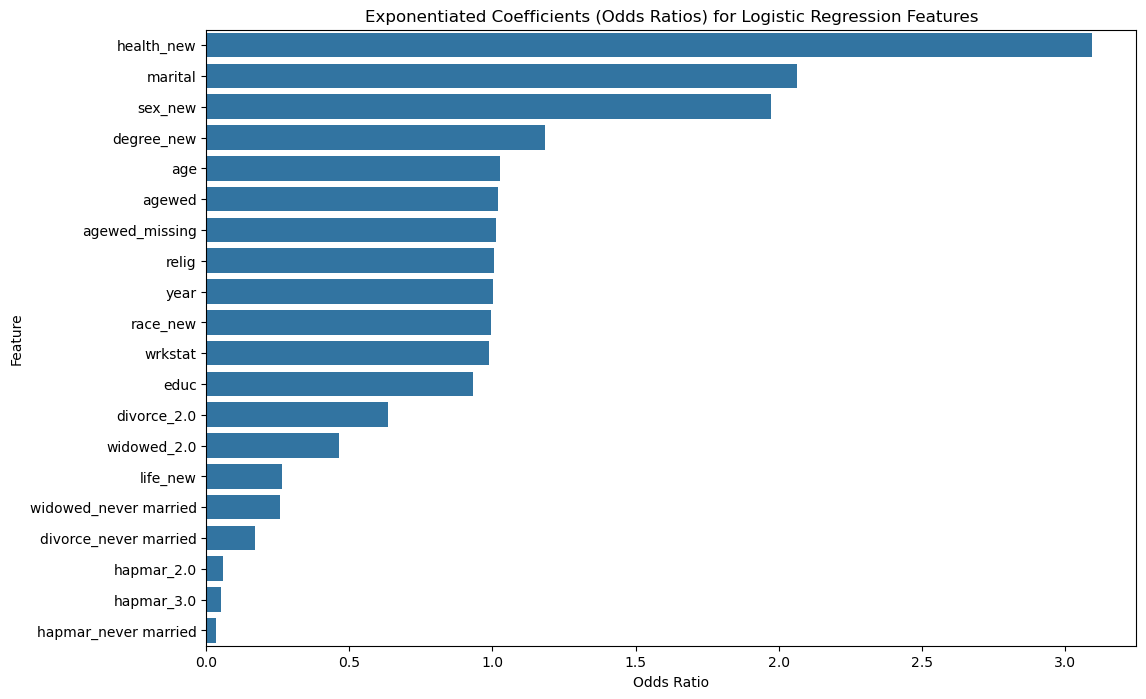

In [241]:
## graph to show value importance
odds_ratios = np.exp(model.coef_[0])
odds_ratios_df = pd.DataFrame({
    'Feature': X.columns,
    'Odds Ratio': odds_ratios
}).sort_values(by='Odds Ratio', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Odds Ratio', y='Feature', data=odds_ratios_df)
plt.title('Exponentiated Coefficients (Odds Ratios) for Logistic Regression Features')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.show()

## Now try doing exact same thing but use Not Too Happy (0) and Pretty Happy (1) as one category and Very Happy (2) as the other

## First Try Without SMOTE

In [242]:
## create new subset data to describe happy_new = 0 and happy_new = 1 to 0 and happy_new = 2 to 1 for interpretability
happy_subset2 = df.copy()
happy_subset2['happy_binary'] = happy_subset2['happy_new'].apply(lambda x: 0 if x == 0 or x == 1 else 1)

## show new encoding
print(happy_subset2[['happy_new', 'happy_binary']].head(10))

   happy_new  happy_binary
0          0             0
1          2             1
2          1             0
3          1             0
4          1             0
5          1             0
6          2             1
7          1             0
8          1             0
9          2             1


In [243]:
## dimensions of data
print(f"Dimensions of the dataset: {happy_subset2.shape}")

## class imbalance
class_counts = happy_subset2['happy_binary'].value_counts()
print("\nClass distribution in 'happy_binary':")
print(class_counts)

Dimensions of the dataset: (40353, 23)

Class distribution in 'happy_binary':
happy_binary
0    27836
1    12517
Name: count, dtype: int64


In [244]:
## define X, Y for logistic regression with happy_binary as the target
X_2 = happy_subset2.drop(columns=['happy_new', 'happy_binary', 'id'])
Y_2 = happy_subset2['happy_binary']

In [245]:
## train test split
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, Y_2, test_size=0.2, random_state=42)

In [246]:
## try without SMOTE first
model_2 = LogisticRegression(max_iter=1000, random_state=42)
model_2.fit(X_train_2, y_train_2)

/opt/anaconda3/envs/env386/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [247]:
## evaluate on test set
y_pred_2 = model.predict(X_test_2)
print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.89      0.58      0.70      5590
           1       0.47      0.84      0.60      2481

    accuracy                           0.66      8071
   macro avg       0.68      0.71      0.65      8071
weighted avg       0.76      0.66      0.67      8071



In [248]:
## feature importance
feature_importance2 = pd.DataFrame({
    'feature': X_train_2.columns,
    'coefficient': model_2.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

print("\nFeature importance based on logistic regression coefficients:")
print(feature_importance2)


Feature importance based on logistic regression coefficients:
                  feature  coefficient
17             hapmar_2.0    -1.942219
19   hapmar_never married    -1.533992
18             hapmar_3.0    -0.996582
11               life_new    -0.978564
10             health_new     0.518754
14  divorce_never married    -0.195092
2                 sex_new     0.168652
7                 marital     0.083566
13            divorce_2.0     0.076181
12         agewed_missing     0.073973
3                race_new    -0.051847
6                   relig    -0.047161
5                    educ    -0.042941
16  widowed_never married    -0.030610
9                 wrkstat     0.027753
4              degree_new     0.012071
15            widowed_2.0    -0.009865
1                     age     0.009518
8                  agewed    -0.001538
0                    year    -0.000048


In [249]:
## identify feature with largest coefficient in absolute value
largest_coef_index2 = np.argmax(abs(model_2.coef_[0]))
print("Feature with the largest coefficient in absolute value:", X_train_2.columns[largest_coef_index2])
print("Largest coefficient value:", model_2.coef_[0][largest_coef_index2])

## turn into log_odds for interpretability
largest_coef_value2 = model_2.coef_[0][largest_coef_index2]
odds_ratio2 = np.exp(largest_coef_value2)
print("Exponentiated coefficient (odds ratio):", odds_ratio2)

Feature with the largest coefficient in absolute value: hapmar_2.0
Largest coefficient value: -1.9422193697816157
Exponentiated coefficient (odds ratio): 0.14338537122663805


In [250]:
## identify feature with coefficient closest to zero
feature_closest_to_zero2 = X_train_2.columns[np.argmin(abs(model_2.coef_[0]))]
print("Feature with coefficient closest to zero:", feature_closest_to_zero2)
closest_to_zero_index2 = np.argmin(abs(model_2.coef_[0]))
closest_to_zero_coef_value2 = model_2.coef_[0][closest_to_zero_index2]
closest_to_zero_odds_ratio2 = np.exp(closest_to_zero_coef_value2)
print("Coefficient closest to zero:", closest_to_zero_coef_value2)
print("Exponentiated coefficient (odds ratio) for the feature closest to zero:", closest_to_zero_odds_ratio2)

Feature with coefficient closest to zero: year
Coefficient closest to zero: -4.787365488171549e-05
Exponentiated coefficient (odds ratio) for the feature closest to zero: 0.9999521274910435


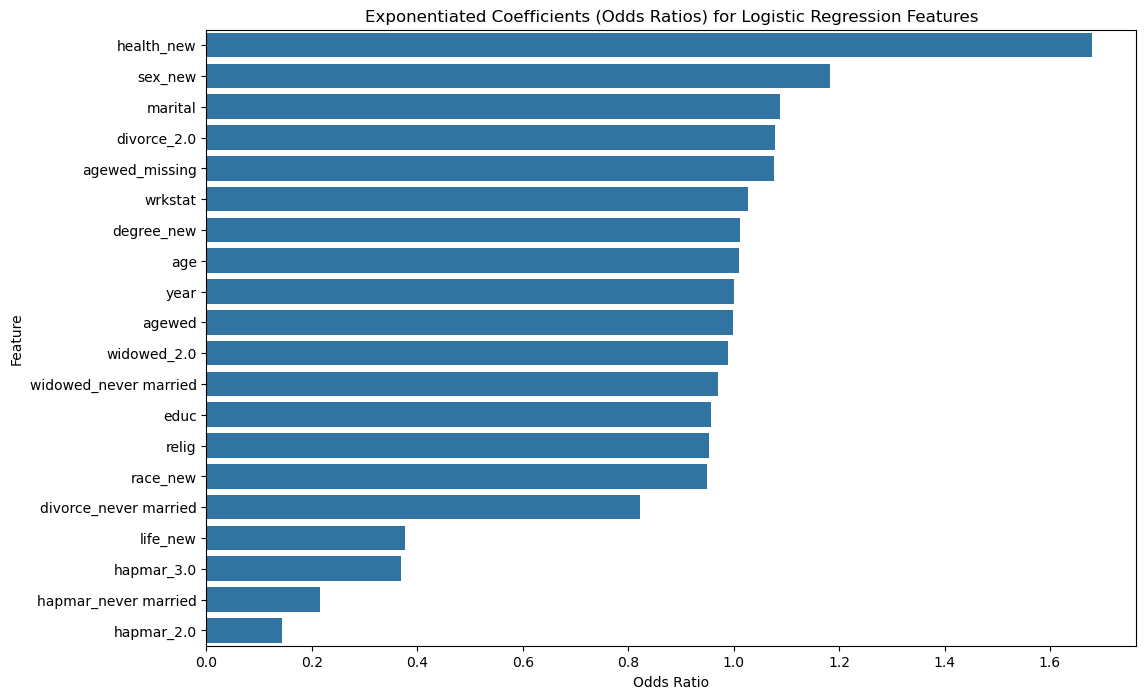

In [251]:
## graph to show value importance
odds_ratios2 = np.exp(model_2.coef_[0])
odds_ratios_df2 = pd.DataFrame({
    'Feature': X_train_2.columns,
    'Odds Ratio': odds_ratios2
}).sort_values(by='Odds Ratio', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Odds Ratio', y='Feature', data=odds_ratios_df2)
plt.title('Exponentiated Coefficients (Odds Ratios) for Logistic Regression Features')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.show()

## try with the SMOTE

In [252]:
smote = SMOTE(random_state=42)
X_train_resampled_2, y_train_resampled_2 = smote.fit_resample(X_train_2, y_train_2)

In [253]:
print(Counter(y_train_resampled_2))

Counter({1: 22246, 0: 22246})


In [254]:
model3 = LogisticRegression(max_iter=1000, random_state=42)
model3.fit(X_train_resampled_2, y_train_resampled_2)

/opt/anaconda3/envs/env386/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [255]:
## classification report for model 3
y_pred_3 = model3.predict(X_test_2)
print(classification_report(y_test_2, y_pred_3))

              precision    recall  f1-score   support

           0       0.83      0.71      0.76      5590
           1       0.50      0.67      0.57      2481

    accuracy                           0.69      8071
   macro avg       0.66      0.69      0.67      8071
weighted avg       0.73      0.69      0.70      8071



In [256]:
## feature importance
feature_importance3 = pd.DataFrame({
    'feature': X_train_resampled_2.columns,
    'coefficient': model3.coef_[0]
}).sort_values(by='coefficient', key=abs, ascending=False)

print("\nFeature importance based on logistic regression coefficients:")
print(feature_importance3)


Feature importance based on logistic regression coefficients:
                  feature  coefficient
17             hapmar_2.0    -1.766544
11               life_new    -1.751375
13            divorce_2.0     0.862902
18             hapmar_3.0    -0.803460
16  widowed_never married     0.784217
19   hapmar_never married    -0.663398
15            widowed_2.0     0.643358
14  divorce_never married     0.602668
3                race_new    -0.427073
2                 sex_new    -0.305424
7                 marital    -0.282181
10             health_new     0.218772
12         agewed_missing     0.080645
4              degree_new    -0.078179
5                    educ    -0.067566
6                   relig    -0.052348
9                 wrkstat     0.034214
8                  agewed    -0.011776
0                    year     0.001467
1                     age    -0.000412


In [257]:
## identify feature with largest coefficient in absolute value
largest_coef_index3 = np.argmax(abs(model3.coef_[0]))
print("Feature with the largest coefficient in absolute value:", X_train_resampled_2.columns[largest_coef_index3])
print("Largest coefficient value:", model3.coef_[0][largest_coef_index3])

## turn into log_odds for interpretability
largest_coef_value3 = model3.coef_[0][largest_coef_index3]
odds_ratio3 = np.exp(largest_coef_value3)
print("Exponentiated coefficient (odds ratio):", odds_ratio3)

Feature with the largest coefficient in absolute value: hapmar_2.0
Largest coefficient value: -1.7665439924144177
Exponentiated coefficient (odds ratio): 0.17092267932735095


In [258]:
## identify feature with coefficient closest to zero
feature_closest_to_zero3 = X_train_resampled_2.columns[np.argmin(abs(model3.coef_[0]))]
print("Feature with coefficient closest to zero:", feature_closest_to_zero3)
closest_to_zero_index3 = np.argmin(abs(model3.coef_[0]))
closest_to_zero_coef_value3 = model3.coef_[0][closest_to_zero_index3]
closest_to_zero_odds_ratio3 = np.exp(closest_to_zero_coef_value3)
print("Coefficient closest to zero:", closest_to_zero_coef_value3)
print("Exponentiated coefficient (odds ratio) for the feature closest to zero:", closest_to_zero_odds_ratio3)

Feature with coefficient closest to zero: age
Coefficient closest to zero: -0.0004124188883021105
Exponentiated coefficient (odds ratio) for the feature closest to zero: 0.9995876661446774


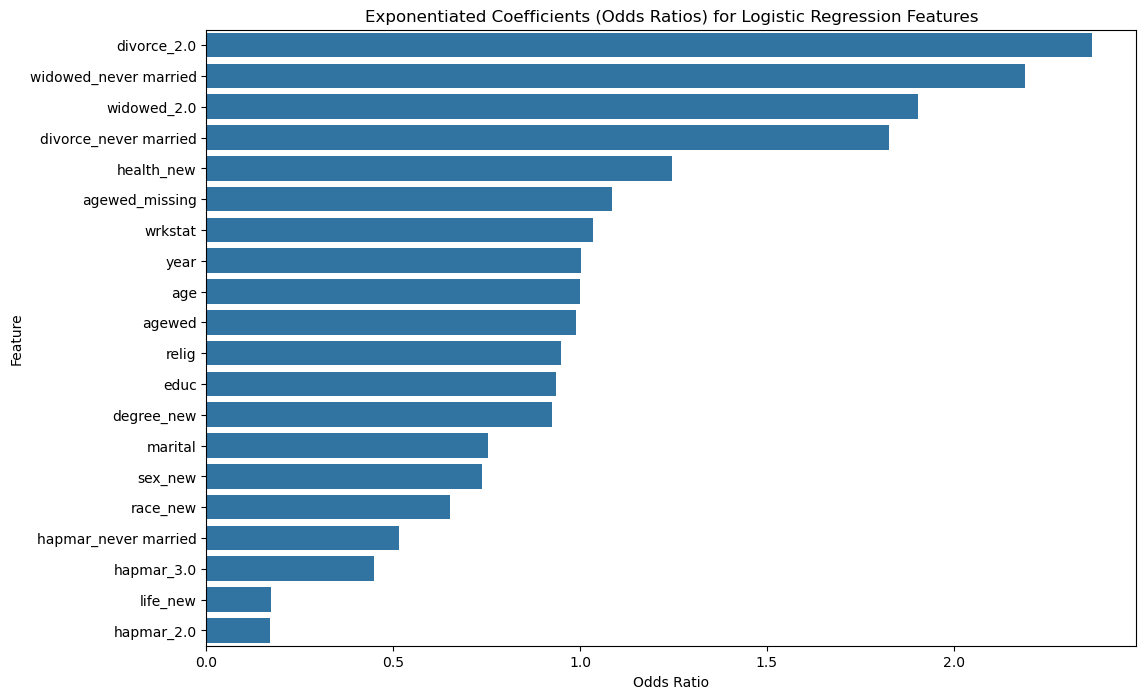

In [259]:
## graph to show value importance
odds_ratios3 = np.exp(model3.coef_[0])
odds_ratios_df3 = pd.DataFrame({
    'Feature': X_train_resampled_2.columns,
    'Odds Ratio': odds_ratios3
}).sort_values(by='Odds Ratio', ascending=False)
plt.figure(figsize=(12, 8))
sns.barplot(x='Odds Ratio', y='Feature', data=odds_ratios_df3)
plt.title('Exponentiated Coefficients (Odds Ratios) for Logistic Regression Features')
plt.xlabel('Odds Ratio')
plt.ylabel('Feature')
plt.show()